In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
 
from afd_vmodel  import afd_vmodel
from afd_explode import afd_explode
from wavemin    import wavemin
from surround   import surround
from near import near

In [2]:
dx = 5 #cdp interval
xmax, zmax = 2500, 1000 #maximum line length and maximum depth
xpinch = 1500 # wedge pinchout coordinates
zwedge = zmax/2 # wedge maximum depth
x = np.arange(0, xmax+dx, dx)  # x coordinate vector
z = np.arange(0, zmax+dx, dx)  # z coordinate vector
vhigh, vlow = 4000, 2000; # high and low velocities

In [3]:
nx = len(x)
nz = len(z)

In [4]:
vel=vlow*np.ones([nz,nx]) #initialize velocity matrix

In [5]:
# define the wedge as a three point polygon
dx2 = dx/2
xpoly = [-dx2, xpinch, -dx2]
zpoly = [-1, -1, zwedge]

In [6]:
#install the wedge in the velocity matrix
vel=afd_vmodel(dx,vel,vhigh,xpoly,zpoly)

In [7]:
#define an anticline beneath the wedge
#x and z of the crest of the anticline
x0=xpinch/2
z0=zwedge+100

a=.0005 # a parameter that determines the steepness of the flanks

za=a*(x-x0)**2+z0 # model the anticline as a parabola

# build a polygon that models the anticline
ind=near(za,zmax+dx)
print('ind is', ind)

ind is [330]


In [8]:
def _near(t: np.ndarray, *args) -> np.ndarray:
    """
    Return indices of samples closest to one or two target values.

    _near(t, t0)          → index of sample nearest t0
    _near(t, t0, t1)      → indices of all samples in [t0, t1] (inclusive)
    """
    t = np.asarray(t)
    if len(args) == 1:
        return np.array([np.argmin(np.abs(t - args[0]))])
    else:
        t0, t1 = args
        return np.where((t >= t0) & (t <= t1))[0]

In [9]:
_near(za, zmax+dx)

array([330])

In [10]:
ind[0]

np.int64(330)

In [11]:
xpoly = np.append(x[0:ind[0]],0)

In [12]:
zpoly = np.append(za[0:ind[0]],za[ind[0]])

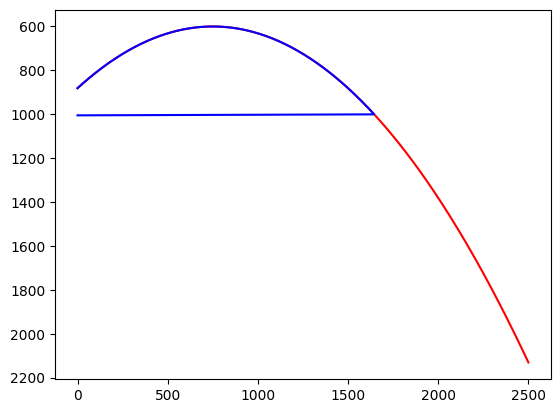

In [13]:
plt.plot(x,za,'r')
plt.plot(xpoly, zpoly,'b')
plt.gca().invert_yaxis()
plt.show()

In [14]:
#install the anticline in the velocity model
vel=afd_vmodel(dx,vel,vhigh,xpoly,zpoly)

In [15]:
vel.shape

(201, 501)

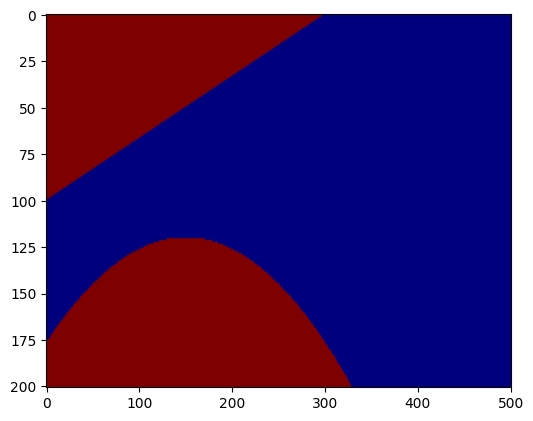

In [16]:
plt.figure(figsize=[6,6])
plt.imshow(vel, cmap='jet', aspect=2)
plt.show()

In [17]:
# bottom layer
xpoly=[0, xmax, xmax, 0]
zpoly=[.9*zmax, .9*zmax, zmax+dx, zmax+dx]
vel=afd_vmodel(dx,vel,vhigh,xpoly,zpoly)

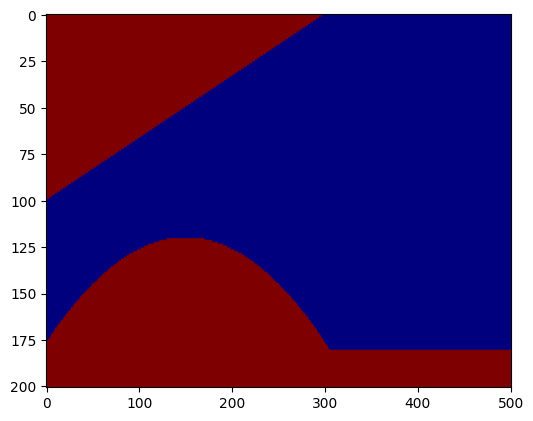

In [18]:
plt.figure(figsize=[6,6])
plt.imshow(vel, cmap='jet', aspect=2)
plt.show()

In [19]:
from ricker import ricker

In [20]:
# do a finite-difference model
dt=.004 #temporal sample rate
dtstep=.001
tmax=2*zmax/vlow #maximum time
#w,tw=wavemin(dt,30,.2) #minimum phase wavelet
src,tw=ricker(dt,70,.2) #ricker wavelet
xrec=x
zrec=x*0

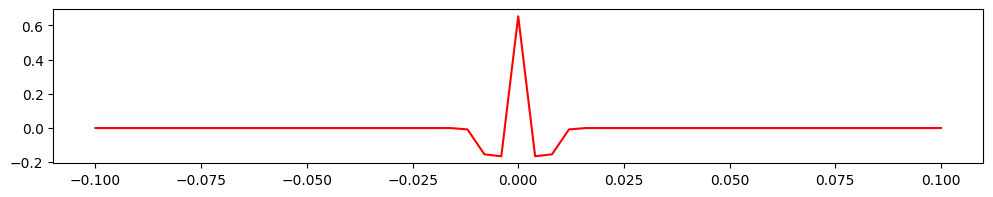

In [21]:
plt.figure(figsize=[12,2])
plt.plot(tw,src,'r')
plt.show()

In [26]:
seis2,seis_unfiltered,t=afd_explode(dx,dtstep,dt,tmax,vel,xrec,zrec,[5,10,40,50],0,2,0);

There are 1000 steps to complete.
  wavefield propagated to 0.0410 s; time left ≈ 1.7 s
  wavefield propagated to 0.0820 s; time left ≈ 1.3 s
  wavefield propagated to 0.1230 s; time left ≈ 1.1 s
  wavefield propagated to 0.1640 s; time left ≈ 1.1 s
  wavefield propagated to 0.2050 s; time left ≈ 1.0 s
  wavefield propagated to 0.2460 s; time left ≈ 0.9 s
  wavefield propagated to 0.2870 s; time left ≈ 0.8 s
  wavefield propagated to 0.3280 s; time left ≈ 0.8 s
  wavefield propagated to 0.3690 s; time left ≈ 0.7 s
  wavefield propagated to 0.4100 s; time left ≈ 0.7 s
  wavefield propagated to 0.4510 s; time left ≈ 0.6 s
  wavefield propagated to 0.4920 s; time left ≈ 0.5 s
  wavefield propagated to 0.5330 s; time left ≈ 0.5 s
  wavefield propagated to 0.5740 s; time left ≈ 0.4 s
  wavefield propagated to 0.6150 s; time left ≈ 0.4 s
  wavefield propagated to 0.6560 s; time left ≈ 0.4 s
  wavefield propagated to 0.6970 s; time left ≈ 0.3 s
  wavefield propagated to 0.7380 s; time left ≈ 

In [23]:
#seis1,seis_unfiltered,t=afd_explode(dx,dtstep,dt,tmax,vel,xrec,zrec,src,tw,2);

len(tw) is  51
len(wlet)is  51
There are 1000 steps to complete.
  wavefield propagated to 0.0410 s; time left ≈ 1.9 s
  wavefield propagated to 0.0820 s; time left ≈ 1.5 s
  wavefield propagated to 0.1230 s; time left ≈ 1.3 s
  wavefield propagated to 0.1640 s; time left ≈ 1.2 s
  wavefield propagated to 0.2050 s; time left ≈ 1.1 s
  wavefield propagated to 0.2460 s; time left ≈ 1.0 s
  wavefield propagated to 0.2870 s; time left ≈ 0.9 s
  wavefield propagated to 0.3280 s; time left ≈ 0.8 s
  wavefield propagated to 0.3690 s; time left ≈ 0.8 s
  wavefield propagated to 0.4100 s; time left ≈ 0.7 s
  wavefield propagated to 0.4510 s; time left ≈ 0.7 s
  wavefield propagated to 0.4920 s; time left ≈ 0.6 s
  wavefield propagated to 0.5330 s; time left ≈ 0.6 s
  wavefield propagated to 0.5740 s; time left ≈ 0.5 s
  wavefield propagated to 0.6150 s; time left ≈ 0.5 s
  wavefield propagated to 0.6560 s; time left ≈ 0.4 s
  wavefield propagated to 0.6970 s; time left ≈ 0.4 s
  wavefield propa

In [29]:
smin,smax=np.percentile(seis2,[1,99])

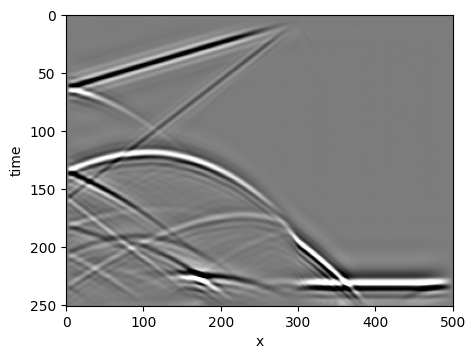

In [30]:
fig2=plt.figure(figsize=[5,5])
plt.imshow(seis2, cmap='gray', vmin=smin, vmax=smax,aspect=1.5)
plt.xlabel('x')
plt.ylabel('time')
plt.show()